In [31]:
# Basic import
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Scikir-learn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# DATA

In [17]:
# Data Import
natgas_df = pd.read_csv("Nat_Gas.csv")
natgas_df["Dates"] = pd.to_datetime(natgas_df["Dates"])

prices = natgas_df["Prices"].values
dates = natgas_df["Dates"]


print(natgas_df.head(5))
print("...")
print(natgas_df.tail(5))

       Dates  Prices
0 2020-10-31    10.1
1 2020-11-30    10.3
2 2020-12-31    11.0
3 2021-01-31    10.9
4 2021-02-28    10.9
...
        Dates  Prices
43 2024-05-31    11.4
44 2024-06-30    11.5
45 2024-07-31    11.6
46 2024-08-31    11.5
47 2024-09-30    11.8


C:\Users\Owner\AppData\Local\Temp\ipykernel_26364\92103257.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  natgas_df["Dates"] = pd.to_datetime(natgas_df["Dates"])


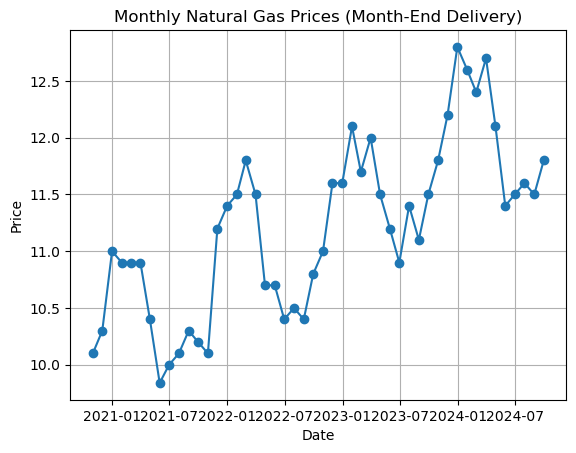

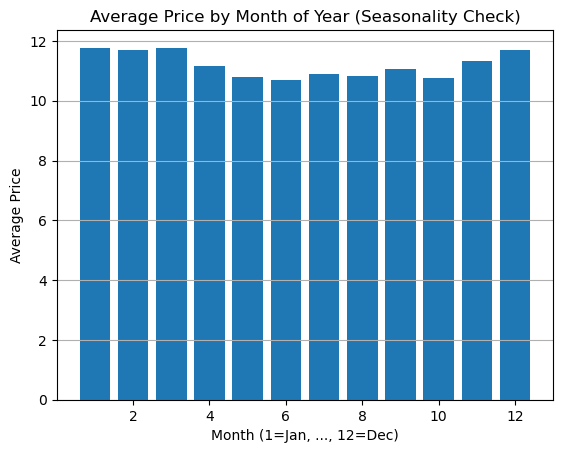

In [18]:
### Data Visualize

# Month-end price over time
plt.figure()
plt.plot(natgas_df["Dates"], natgas_df["Prices"], marker="o")
plt.title("Monthly Natural Gas Prices (Month-End Delivery)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# Average price by calendar month
natgas_df["Month"] = natgas_df["Dates"].dt.month
month_avg = natgas_df.groupby("Month")["Prices"].mean()

plt.figure()
plt.bar(month_avg.index, month_avg.values)
plt.title("Average Price by Month of Year (Seasonality Check)")
plt.xlabel("Month (1=Jan, ..., 12=Dec)")
plt.ylabel("Average Price")
plt.grid(axis="y")
plt.show()

The above chart shows:
- Trend: Prices increase over time
- Seasonality: Price rise in the winter and dip in the summer

# INTERPOLATE

Why? => Since the data provided is only monthly, in order to get the daily price, linear interpolation is used since it is defensible, simple and consistent. Interpolation for this case means that it assumes the best neutral guess for any date between 2 observed month-end prices is a straight line.

How? => use np.interp() but this only works with numbers and dates are not a number => use datetime64 to convert np.interp(x, xp, fp)

x: the estimated point (integer), xp: array of x values (integer), fp: array of y values
In this case: x is the date that needs to be estimated, xp is data_int, fp is price_vals

In [19]:
from data_0 import natgas_df, pd, plt, np


date_int = natgas_df["Dates"].values.astype("datetime64[D]").astype(int)
price_vals = natgas_df["Prices"].values

def interpolate_price(query_date):
    q = pd.to_datetime(query_date)
    q_int = q.to_datetime64().astype("datetime64[D]").astype(int)
    return float(np.interp(q_int, date_int, price_vals))

# Test
print("Interpolation check (15/12/2022):",interpolate_price("2022-11-15"))

Interpolation check (15/12/2022): 11.3


# EXTRAPOLATE

Why? => The current data ended in September 2024, while a contract might need the price in 2025, which is outside the provided data range. So there is a need to forecast future prices.

## Convert dates into model inputs

One approach to this issue is to learn the trend and seasonality of the provided data. The above charts show prices gradually increasing over time (Trend) and prices rise in the winter, dip in the summer (Seasonality). =>The trend and seasonality are clear, so the question now is how the model can understand them.
- Seasonality is tricky since month numbers from 1 to 12 need to be put in a cycle => sin(2pi * month / 12) and cos(2pi * month / 12). Explain:
    + Since 1 to 12 are put in a cycle, they will be like a clock with 12 points on it. The use of the formula will identify the position of each point accordingly through its degree, and this will be understood by the regression model.
    + Both sin and cos are required because there is a need to differentiate different points as sin(30) = sin(150), which means January and May are at the same position, but cos(30) != cos(150). So, the (sin, cos) pair will give every month a unique coordinate.
- Trend is simple since there is only one need to measure how many days have passed since the start => Use t as days since start. However, the trend doesn't increase in a straight line but rather increases at a changing rate => Add t^2 to represent such a curve.

In order to build the model, there needs to be a fixed start date (the earliest date in the dataset), calculate t, the angle and finally, combine t, t^2, sin, and cos.
- t is the difference between the chosen date and the start date => .dt.days to get the number of day
- month is just .dt.month of the chosen date
- Both t and month need to be => .values.reshape() to turn into 2D array to be usable in np.interp(

In [20]:
start_date = natgas_df["Dates"].min()

def make_features(dates):
    dates = pd.Series(pd.to_datetime(dates))
    
    # Trend
    t = (dates - start_date).dt.days.values.reshape(-1, 1)
    t2 = t**2
    
    # Seasonality
    ## Putting 12 months into a cycle so the model can understand
    m = dates.dt.month.values.reshape(-1, 1)
    angle = 2 * np.pi * m / 12
    sin1 = np.sin(angle)
    cos1 = np.cos(angle)
    
    return np.hstack([t, t2, sin1, cos1])

print(np.shape(make_features("2025-09-22")))

(1, 4)


## Automatic function to interpolate and extrapolate

In this step, using make_features() to actually fit the Ridge regression wrapped in a sklearn Pipeline with a StandardScaler.
- Why Ridge? => Linear regression could be used here but it could lead to overfitting (finding best fit at any cost) due to the fact that t and t^2 are closely related  => Meanwhile, Ridge regression will adds a penalty for large weights, forcing the model to keep coefficients small and sensible =>  use alpha = 1 (default, Higher alpha = more penalty = simpler and smoother model, behaving less like linear regression) => This will help find the good fit while keeping the model stable and generalizable
- Why StandardScaler? => In make_features, the value of t^2 is a very huge number while sin and cos are tiny, so it could lead to the model falsy assume that t^2 is more important => Therefore, StandardScaler is used to rescales every feature to have mean 0 and STDV 1 => so that all features are on the same playing field => StandardScaler is needed before Ridge
=> use model to build a "Pipeline"
=> Call model.predict(X, y), in which X is the input and y is the output

After model fit, a unified pricing function is needed that:
- Takes any date as input. If:
    - Within your observed data → uses interpolate()
    - Beyond your observed data → uses model.predict()
    - Too far into the future → raises an error => So what is the limit? 1 year as it will cover enough the 12 months seasonal pattern while still being reliable compared to 2 or 3 years horizon, which are more uncertain. 

In [21]:
# Build model Pipeline and predict price with the given date input
model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

X = make_features(natgas_df["Dates"])
y = price_vals

model.fit(X, y)

# forecast limit = last observed date + 1 years
last_date = natgas_df["Dates"].max()
forecast_lim = last_date + pd.Timedelta(days=365) 

# function to estimate price
def estimate_gas_price(date_input):
    date_input = pd.to_datetime(date_input)

    # if date is within observed data => interpolate
    if date_input <= last_date:
        return interpolate_price(date_input)
    # if date is within forecast limit => model.predict
    elif date_input <= forecast_lim:
        return float(model.predict(make_features(date_input))[0])
    # Error
    else:
         raise ValueError("Date beyong forecast limit")
            
print(estimate_gas_price("2025-09-30"))

12.58679031283382


## Plot extrapolate price

Step:
- Generate future dates => pd.date_range()
- Generate pedicted prices for those dates => estimate_gas_price() or model.predict(make_features())
- Plot price: observed and predicted

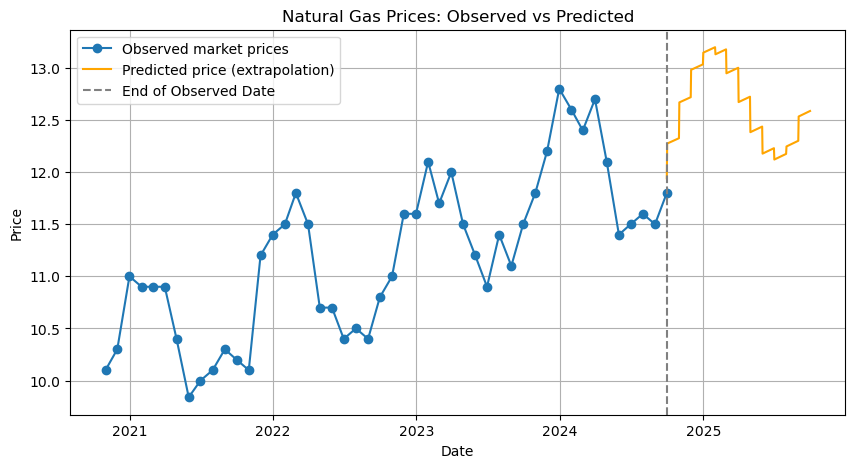

In [22]:
# Plot extrapolate price

## Generate full date
futures_dates = pd.date_range(start = last_date, end = forecast_lim, freq = "D")

## Generate price
future_features = make_features(futures_dates)
future_prices = model.predict(future_features)

## Plot observed price
plt.figure(figsize=(10,5))

## Observed price
plt.plot(natgas_df["Dates"], 
         price_vals, 
         marker = "o",
         label = "Observed market prices"
        )
## Predicted price
plt.plot(futures_dates, 
         future_prices,
         color = "orange",
         label = "Predicted price (extrapolation)"
        )

## Add seperate date line
plt.axvline(last_date, 
            linestyle = "--", 
            color = "grey", 
            label = "End of Observed Date"
           )

plt.title("Natural Gas Prices: Observed vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Test
print("Price Estimates")
print("Past date (31/12/2022):", estimate_gas_price("2022-12-31"))
print("Last observed (30/09/2024):", estimate_gas_price("2024-09-30"))
print("Future date (30/04/2025):", estimate_gas_price("2022-04-30"))

Price Estimates
Past date (31/12/2022): 11.6
Last observed (30/09/2024): 11.8
Future date (30/04/2025): 10.7


## Validation

Why? To check if the model predicts the past well, so that we can be more confidence about the extrapolation result above.

Method: Since the predict period is 1 year, the test data is also set to be 1 year from (30/09/2023 to 30/9/2024) to reflect the equivalent. So, the cut-off point for the train/split will be 30/9/2023

In [40]:
# Validation

## Cut-off (75% of data for training)
cutoff = pd.to_datetime("2023-09-30")
train = natgas_df[natgas_df["Dates"] <= cutoff]
test  = natgas_df[natgas_df["Dates"] > cutoff]

## Fit the model with training
model.fit(make_features(train["Dates"]), train["Prices"].values)

## Predict price for the test dates
y_pred = model.predict(make_features(test["Dates"]))
y_actual = test["Prices"].values

## Predict vs Actual
print("Coefficient of determination:", r2_score(y_actual, y_pred))

Coefficient of determination: 0.619065724717438


A score of 0.62 means the model correctly predicted the direction and rough level of prices 62% of the time on unseen data. For a model with only 4 inputs (trend, curve, winter/summer cycle), this is a reasonable result. It's good enough to use as a starting point for pricing a storage contract, but the prices it produces should be treated as estimates, not exact figures.

# PRICING MODEL

As the price data is somewhat complete, a pricing model is needed to automate and track the buy, hold and sell process as well as tracking the process. In simple word, the point of the pricing model is to calculate the net profit after all cost.
=> Build a function and in order to price a contract, we need to answer When we are buying and selling gas, how much gas are moved each time, Whether there are any physical limits and Whether there are anh cost.
- Price => since there is estimate_gas_price function => the actual input needed here is date => injection and withdrawal dates
- Volumne => injection
- Limit
- Cost

In [11]:
def price_storage_contract(inj_date,
                           wdr_date,
                           inj_vol,
                           wdr_vol,
                           
)

SyntaxError: expected ':' (683356121.py, line 6)